In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

STEP 1 — Understand our actual dataset

STEP 2 — Import libraries

STEP 3 — Load the dataset

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


STEP 4 — Check dataset size

In [4]:
df.shape

(918, 12)

STEP 5 — Understand the columns

In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


STEP 6 — Check missing values

In [8]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

STEP 7 — Find those suspicious zeros

In [9]:
print("Cholesterol zeros:", (df["Cholesterol"] == 0).sum())
print("RestingBP zeros:", (df["RestingBP"] == 0).sum())

Cholesterol zeros: 172
RestingBP zeros: 1


STEP 8 — Check duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df[df.duplicated()]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


STEP 9 — Check target distribution

In [12]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

STEP 10 — Very important improvement: don't preprocess before splitting

In [13]:
df["HeartDisease"].value_counts(normalize=True) * 100

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

STEP 11 — Separate X and y

In [14]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [15]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (918, 11)
y shape: (918,)


STEP 12 — Train-test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (734, 11)
Testing data: (184, 11)


In [18]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train.loc[X_train["Cholesterol"] == 0, "Cholesterol"] = np.nan
X_test.loc[X_test["Cholesterol"] == 0, "Cholesterol"] = np.nan

X_train.loc[X_train["RestingBP"] == 0, "RestingBP"] = np.nan
X_test.loc[X_test["RestingBP"] == 0, "RestingBP"] = np.nan

Import preprocessing tools

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

Define numerical and categorical columns

In [20]:
numeric_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

In [21]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

Categorical features:
['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


Create numerical preprocessing

In [22]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [23]:
SimpleImputer(strategy="median")

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [24]:
StandardScaler()

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Create categorical preprocessing

In [25]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

Combine both pipelines

In [26]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

Test the preprocessing

In [27]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [28]:
preprocessor.fit_transform(X_train)

array([[ 0.9700116 ,  0.3390158 , -0.51749887, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.12202766, -1.26603098, -0.57283478, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.54601963, -0.15910217,  1.71438305, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.54601963, -0.60187369, -0.22237398, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.75801561, -0.43583437,  0.86589901, ...,  0.        ,
         0.        ,  1.        ],
       [-0.93795226,  0.39436224, -0.38838173, ...,  0.        ,
         0.        ,  1.        ]], shape=(734, 21))

In [29]:
preprocessor.transform(X_test)

array([[-0.83195427, -0.98929878, -0.13014746, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.44002164, -0.04840928, -0.38838173, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.65201762, -0.43583437,  0.23875864, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.51396029, -0.15910217, -0.13014746, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.54601963, -1.26603098, -0.11170215, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.33402364, -1.54276319, -0.13014746, ...,  0.        ,
         1.        ,  0.        ]], shape=(184, 21))

In [30]:
preprocessor.fit_transform(X_test)

array([[-0.66417717, -0.92219075, -0.05255689, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.62903552,  0.04580008, -0.23540187, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.84457097, -0.35278438,  0.45534583, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.340874  , -0.0680812 , -0.05255689, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.73680324, -1.20689393,  0.06933976, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.5212678 , -1.49159711, -0.05255689, ...,  0.        ,
         1.        ,  0.        ]], shape=(184, 21))

Check the result

In [31]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (734, 11)
Processed training shape: (734, 21)
Original testing shape: (184, 11)
Processed testing shape: (184, 21)


Verify there are no missing values after preprocessing

In [32]:
print("Missing values in training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in testing data:",
      np.isnan(X_test_processed).sum())

Missing values in training data: 0
Missing values in testing data: 0


Train our first model: Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [35]:
logistic_model.fit(X_train_processed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [36]:
y_pred_lr = logistic_model.predict(X_test_processed)

In [37]:
print(y_pred_lr[:20])

[1 0 1 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0]


In [38]:
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

Evaluate Logistic Regression

In [39]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)

f1_lr = f1_score(y_test, y_pred_lr)

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

cm_lr = confusion_matrix(y_test, y_pred_lr)

In [40]:
print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1 Score :", round(f1_lr, 4))
print("ROC-AUC  :", round(roc_auc_lr, 4))

Logistic Regression Results
--------------------------------
Accuracy : 0.8859
Precision: 0.8857
Recall   : 0.9118
F1 Score : 0.8986
ROC-AUC  : 0.9329


Calculate Specificity

In [41]:
tn, fp, fn, tp = cm_lr.ravel()

specificity_lr = tn / (tn + fp)

print("Specificity:", round(specificity_lr, 4))

Specificity: 0.8537


classification report

In [42]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



Confusion Matrix

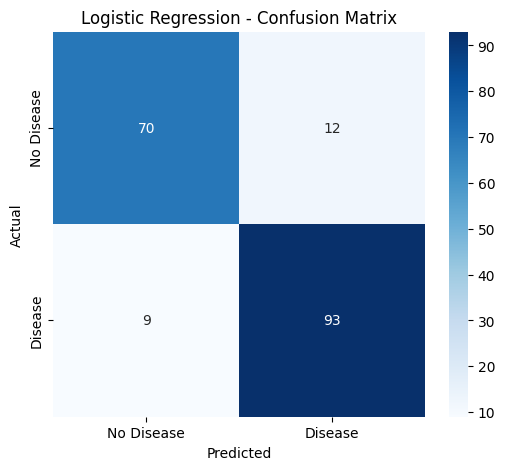

In [43]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Decision Tree

In [44]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [46]:
decision_tree.fit(X_train_processed, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [47]:
y_pred_dt = decision_tree.predict(X_test_processed)

In [48]:
print(y_pred_dt[:20])

[1 1 1 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0]


In [49]:
y_prob_dt = decision_tree.predict_proba(X_test_processed)[:, 1]

In [50]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(y_test, y_pred_dt)

recall_dt = recall_score(y_test, y_pred_dt)

f1_dt = f1_score(y_test, y_pred_dt)

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

cm_dt = confusion_matrix(y_test, y_pred_dt)

tn, fp, fn, tp = cm_dt.ravel()

specificity_dt = tn / (tn + fp)

Metrics results

In [51]:
print("Decision Tree Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1 Score :", round(f1_dt, 4))
print("ROC-AUC  :", round(roc_auc_dt, 4))
print("Specificity:", round(specificity_dt, 4))

Decision Tree Results
--------------------------------
Accuracy : 0.7772
Precision: 0.8211
Recall   : 0.7647
F1 Score : 0.7919
ROC-AUC  : 0.7787
Specificity: 0.7927


Classification report

In [52]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.73      0.79      0.76        82
           1       0.82      0.76      0.79       102

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.78      0.78      0.78       184



Confusion Matrix

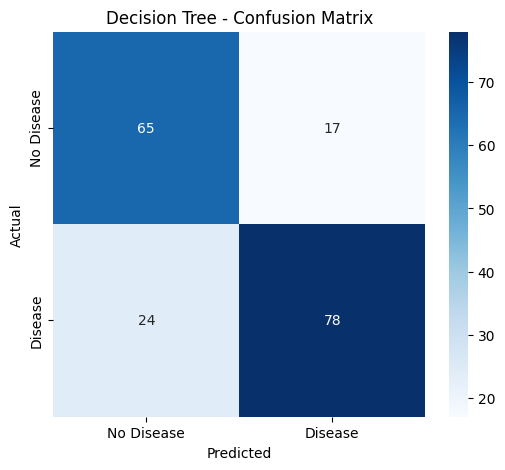

In [53]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [56]:
random_forest.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [57]:
y_pred_rf = random_forest.predict(X_test_processed)

In [58]:
print(y_pred_rf[:20])

[1 0 1 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0]


In [59]:
y_prob_rf = random_forest.predict_proba(X_test_processed)[:, 1]

In [60]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)

tn, fp, fn, tp = cm_rf.ravel()

specificity_rf = tn / (tn + fp)

Display results

In [61]:
print("Random Forest Results")
print("--------------------------------")
print("Accuracy   :", round(accuracy_rf, 4))
print("Precision  :", round(precision_rf, 4))
print("Recall     :", round(recall_rf, 4))
print("F1 Score   :", round(f1_rf, 4))
print("ROC-AUC    :", round(roc_auc_rf, 4))
print("Specificity:", round(specificity_rf, 4))

Random Forest Results
--------------------------------
Accuracy   : 0.8804
Precision  : 0.8846
Recall     : 0.902
F1 Score   : 0.8932
ROC-AUC    : 0.9328
Specificity: 0.8537


Classification report

In [62]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



Confusion Matrix

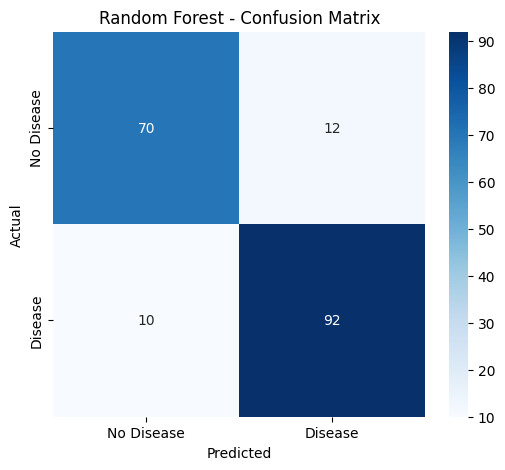

In [63]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

SVM

In [64]:
from sklearn.svm import SVC

In [65]:
from sklearn.svm import SVC

In [66]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

In [67]:
svm_model.fit(X_train_processed, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [68]:
y_pred_svm = svm_model.predict(X_test_processed)

In [69]:
y_prob_svm = svm_model.predict_proba(X_test_processed)[:, 1]

In [70]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(y_test, y_pred_svm)

recall_svm = recall_score(y_test, y_pred_svm)

f1_svm = f1_score(y_test, y_pred_svm)

roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

cm_svm = confusion_matrix(y_test, y_pred_svm)

tn, fp, fn, tp = cm_svm.ravel()

specificity_svm = tn / (tn + fp)

In [71]:
print("SVM Results")
print("--------------------------------")
print("Accuracy   :", round(accuracy_svm, 4))
print("Precision  :", round(precision_svm, 4))
print("Recall     :", round(recall_svm, 4))
print("F1 Score   :", round(f1_svm, 4))
print("ROC-AUC    :", round(roc_auc_svm, 4))
print("Specificity:", round(specificity_svm, 4))

SVM Results
--------------------------------
Accuracy   : 0.8696
Precision  : 0.8679
Recall     : 0.902
F1 Score   : 0.8846
ROC-AUC    : 0.9411
Specificity: 0.8293


Classification report

In [72]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85        82
           1       0.87      0.90      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



Confusion matrix

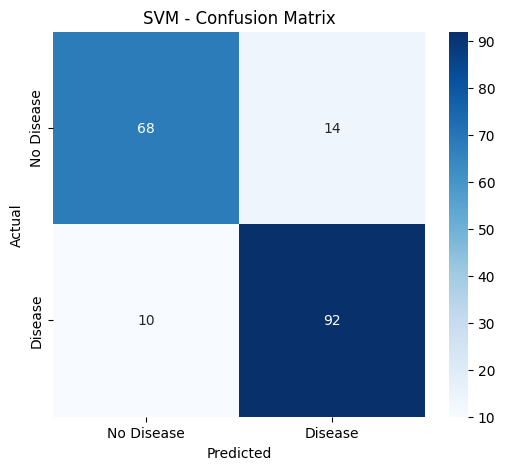

In [73]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Confusion Matrix")
plt.show()

Create our proper model comparison table

In [74]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_svm
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_svm
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_svm
    ],

    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_svm
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_svm
    ],

    "Specificity": [
        specificity_lr,
        specificity_dt,
        specificity_rf,
        specificity_svm
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Specificity
0,Logistic Regression,0.885870,0.885714,0.911765,0.898551,0.932927,0.853659
1,Decision Tree,0.777174,0.821053,0.764706,0.791878,0.778694,0.792683
2,Random Forest,0.880435,0.884615,0.901961,0.893204,0.932807,0.853659
3,SVM,0.869565,0.867925,0.901961,0.884615,0.941117,0.829268


In [75]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Specificity
0,Logistic Regression,0.8859,0.8857,0.9118,0.8986,0.9329,0.8537
1,Decision Tree,0.7772,0.8211,0.7647,0.7919,0.7787,0.7927
2,Random Forest,0.8804,0.8846,0.9020,0.8932,0.9328,0.8537
3,SVM,0.8696,0.8679,0.9020,0.8846,0.9411,0.8293


Hyperparameter Tuning

Tune Logistic Regression first

In [76]:
from sklearn.model_selection import GridSearchCV

In [77]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

Define Logistic Regression parameters

In [78]:
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

Create GridSearchCV

In [79]:
lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

Train GridSearch

In [80]:
lr_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [81]:
X_train

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
485,63,M,ATA,139.0,217.0,1,ST,128,Y,1.2,Flat
486,55,M,ATA,110.0,214.0,1,ST,180,N,0.4,Up
117,59,F,ASY,130.0,338.0,1,ST,130,Y,1.5,Flat
361,47,M,ASY,160.0,NaN,0,Normal,124,Y,0.0,Flat
296,50,M,ASY,145.0,NaN,1,Normal,139,Y,0.7,Flat
...,...,...,...,...,...,...,...,...,...,...,...
276,51,M,NAP,135.0,160.0,0,Normal,150,N,2.0,Flat
201,46,M,NAP,120.0,230.0,0,Normal,150,N,0.0,Up
462,59,M,ASY,122.0,233.0,0,Normal,117,Y,1.3,Down
252,61,M,ASY,125.0,292.0,0,ST,115,Y,0.0,Up


See the best parameters

In [82]:
print("Best Parameters:")
print(lr_grid.best_params_)

Best Parameters:
{'model__C': 0.1, 'model__class_weight': None, 'model__solver': 'lbfgs'}


In [83]:
print("Best Cross-Validation ROC-AUC:")
print(round(lr_grid.best_score_, 4))

Best Cross-Validation ROC-AUC:
0.9172


Evaluate tuned Logistic Regression

In [84]:
best_lr = lr_grid.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test)

y_prob_lr_tuned = best_lr.predict_proba(X_test)[:, 1]

In [85]:
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)

precision_lr_tuned = precision_score(y_test, y_pred_lr_tuned)

recall_lr_tuned = recall_score(y_test, y_pred_lr_tuned)

f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned)

roc_auc_lr_tuned = roc_auc_score(y_test, y_prob_lr_tuned)

cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

tn, fp, fn, tp = cm_lr_tuned.ravel()

specificity_lr_tuned = tn / (tn + fp)

In [86]:
print("Tuned Logistic Regression")
print("--------------------------------")
print("Accuracy   :", round(accuracy_lr_tuned, 4))
print("Precision  :", round(precision_lr_tuned, 4))
print("Recall     :", round(recall_lr_tuned, 4))
print("F1 Score   :", round(f1_lr_tuned, 4))
print("ROC-AUC    :", round(roc_auc_lr_tuned, 4))
print("Specificity:", round(specificity_lr_tuned, 4))

Tuned Logistic Regression
--------------------------------
Accuracy   : 0.8913
Precision  : 0.8942
Recall     : 0.9118
F1 Score   : 0.9029
ROC-AUC    : 0.9346
Specificity: 0.8659


Tune Decision Tree

In [87]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

In [88]:
dt_param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced"]
}

Run GridSearchCV

In [89]:
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [90]:
dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

Check the best Decision Tree

In [91]:
print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(dt_grid.best_score_, 4))

Best Decision Tree Parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}

Best Cross-Validation ROC-AUC:
0.9071


Evaluate the tuned tree

In [92]:
best_dt = dt_grid.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test)
y_prob_dt_tuned = best_dt.predict_proba(X_test)[:, 1]

In [93]:
accuracy_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)

precision_dt_tuned = precision_score(y_test, y_pred_dt_tuned)

recall_dt_tuned = recall_score(y_test, y_pred_dt_tuned)

f1_dt_tuned = f1_score(y_test, y_pred_dt_tuned)

roc_auc_dt_tuned = roc_auc_score(y_test, y_prob_dt_tuned)

cm_dt_tuned = confusion_matrix(y_test, y_pred_dt_tuned)

tn, fp, fn, tp = cm_dt_tuned.ravel()

specificity_dt_tuned = tn / (tn + fp)

In [94]:
print("Tuned Decision Tree")
print("--------------------------------")
print("Accuracy   :", round(accuracy_dt_tuned, 4))
print("Precision  :", round(precision_dt_tuned, 4))
print("Recall     :", round(recall_dt_tuned, 4))
print("F1 Score   :", round(f1_dt_tuned, 4))
print("ROC-AUC    :", round(roc_auc_dt_tuned, 4))
print("Specificity:", round(specificity_dt_tuned, 4))

Tuned Decision Tree
--------------------------------
Accuracy   : 0.8207
Precision  : 0.871
Recall     : 0.7941
F1 Score   : 0.8308
ROC-AUC    : 0.889
Specificity: 0.8537


Tune Random Forest

In [95]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

In [96]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

Create GridSearchCV

In [97]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [98]:
rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

See the best parameters

In [99]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(rf_grid.best_score_, 4))

Best Random Forest Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}

Best Cross-Validation ROC-AUC:
0.9285


Evaluate the tuned Random Forest

In [100]:
best_rf = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

In [101]:
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)

precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)

recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned)

f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)

roc_auc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)

cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

tn, fp, fn, tp = cm_rf_tuned.ravel()

specificity_rf_tuned = tn / (tn + fp)

Print the results

In [102]:
print("Tuned Random Forest")
print("--------------------------------")
print("Accuracy   :", round(accuracy_rf_tuned, 4))
print("Precision  :", round(precision_rf_tuned, 4))
print("Recall     :", round(recall_rf_tuned, 4))
print("F1 Score   :", round(f1_rf_tuned, 4))
print("ROC-AUC    :", round(roc_auc_rf_tuned, 4))
print("Specificity:", round(specificity_rf_tuned, 4))

Tuned Random Forest
--------------------------------
Accuracy   : 0.8859
Precision  : 0.8716
Recall     : 0.9314
F1 Score   : 0.9005
ROC-AUC    : 0.9301
Specificity: 0.8293


Classification report

In [103]:
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



Confusion matrix

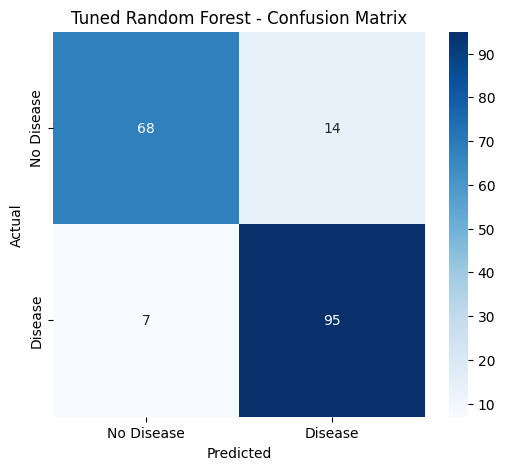

In [104]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

Tune SVM

In [105]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

In [106]:
svm_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["rbf", "linear"],
    "model__gamma": ["scale", "auto"],
    "model__class_weight": [None, "balanced"]
}

Create GridSearchCV

In [107]:
svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [108]:
svm_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__class_weight': [None, 'balanced'], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

Check best SVM parameters

In [109]:
print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(svm_grid.best_score_, 4))

Best SVM Parameters:
{'model__C': 100, 'model__class_weight': 'balanced', 'model__gamma': 'scale', 'model__kernel': 'linear'}

Best Cross-Validation ROC-AUC:
0.9193


Evaluate tuned SVM

In [110]:
best_svm = svm_grid.best_estimator_

y_pred_svm_tuned = best_svm.predict(X_test)

y_prob_svm_tuned = best_svm.predict_proba(X_test)[:, 1]

In [111]:
accuracy_svm_tuned = accuracy_score(y_test, y_pred_svm_tuned)

precision_svm_tuned = precision_score(y_test, y_pred_svm_tuned)

recall_svm_tuned = recall_score(y_test, y_pred_svm_tuned)

f1_svm_tuned = f1_score(y_test, y_pred_svm_tuned)

roc_auc_svm_tuned = roc_auc_score(y_test, y_prob_svm_tuned)

cm_svm_tuned = confusion_matrix(y_test, y_pred_svm_tuned)

tn, fp, fn, tp = cm_svm_tuned.ravel()

specificity_svm_tuned = tn / (tn + fp)

Result

In [112]:
print("Tuned SVM")
print("--------------------------------")
print("Accuracy   :", round(accuracy_svm_tuned, 4))
print("Precision  :", round(precision_svm_tuned, 4))
print("Recall     :", round(recall_svm_tuned, 4))
print("F1 Score   :", round(f1_svm_tuned, 4))
print("ROC-AUC    :", round(roc_auc_svm_tuned, 4))
print("Specificity:", round(specificity_svm_tuned, 4))

Tuned SVM
--------------------------------
Accuracy   : 0.8641
Precision  : 0.914
Recall     : 0.8333
F1 Score   : 0.8718
ROC-AUC    : 0.9268
Specificity: 0.9024


In [113]:
print(classification_report(y_test, y_pred_svm_tuned))

              precision    recall  f1-score   support

           0       0.81      0.90      0.86        82
           1       0.91      0.83      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



confusion matrix:

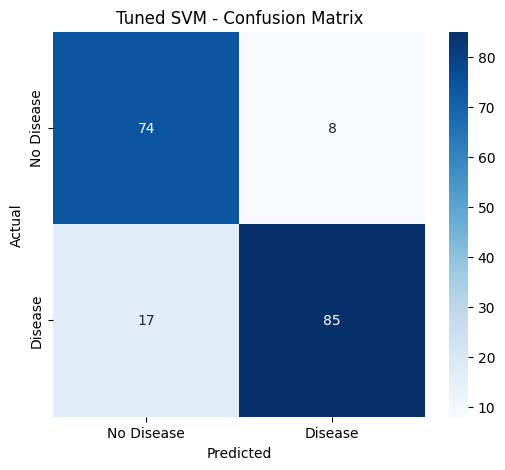

In [114]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned SVM - Confusion Matrix")
plt.show()

final comparison table

In [116]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Tuned Logistic Regression",
        "Tuned Decision Tree",
        "Tuned Random Forest",
        "Tuned SVM"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_svm,
        accuracy_lr_tuned,
        accuracy_dt_tuned,
        accuracy_rf_tuned,
        accuracy_svm_tuned
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_svm,
        precision_lr_tuned,
        precision_dt_tuned,
        precision_rf_tuned,
        precision_svm_tuned
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_svm,
        recall_lr_tuned,
        recall_dt_tuned,
        recall_rf_tuned,
        recall_svm_tuned
    ],

    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_svm,
        f1_lr_tuned,
        f1_dt_tuned,
        f1_rf_tuned,
        f1_svm_tuned
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_svm,
        roc_auc_lr_tuned,
        roc_auc_dt_tuned,
        roc_auc_rf_tuned,
        roc_auc_svm_tuned
    ],

    "Specificity": [
        specificity_lr,
        specificity_dt,
        specificity_rf,
        specificity_svm,
        specificity_lr_tuned,
        specificity_dt_tuned,
        specificity_rf_tuned,
        specificity_svm_tuned
    ]
})

final_results = final_results.round(4)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Specificity
0,Logistic Regression,0.8859,0.8857,0.9118,0.8986,0.9329,0.8537
1,Decision Tree,0.7772,0.8211,0.7647,0.7919,0.7787,0.7927
2,Random Forest,0.8804,0.8846,0.9020,0.8932,0.9328,0.8537
3,SVM,0.8696,0.8679,0.9020,0.8846,0.9411,0.8293
4,Tuned Logistic Regression,0.8913,0.8942,0.9118,0.9029,0.9346,0.8659
5,Tuned Decision Tree,0.8207,0.8710,0.7941,0.8308,0.8890,0.8537
6,Tuned Random Forest,0.8859,0.8716,0.9314,0.9005,0.9301,0.8293
7,Tuned SVM,0.8641,0.9140,0.8333,0.8718,0.9268,0.9024


Sort the models

best by accuracy:

In [117]:
final_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Specificity
4,Tuned Logistic Regression,0.8913,0.8942,0.9118,0.9029,0.9346,0.8659
0,Logistic Regression,0.8859,0.8857,0.9118,0.8986,0.9329,0.8537
6,Tuned Random Forest,0.8859,0.8716,0.9314,0.9005,0.9301,0.8293
2,Random Forest,0.8804,0.8846,0.9020,0.8932,0.9328,0.8537
3,SVM,0.8696,0.8679,0.9020,0.8846,0.9411,0.8293
7,Tuned SVM,0.8641,0.9140,0.8333,0.8718,0.9268,0.9024
5,Tuned Decision Tree,0.8207,0.8710,0.7941,0.8308,0.8890,0.8537
1,Decision Tree,0.7772,0.8211,0.7647,0.7919,0.7787,0.7927


check by Recall:

In [118]:
final_results.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Specificity
6,Tuned Random Forest,0.8859,0.8716,0.9314,0.9005,0.9301,0.8293
0,Logistic Regression,0.8859,0.8857,0.9118,0.8986,0.9329,0.8537
4,Tuned Logistic Regression,0.8913,0.8942,0.9118,0.9029,0.9346,0.8659
2,Random Forest,0.8804,0.8846,0.9020,0.8932,0.9328,0.8537
3,SVM,0.8696,0.8679,0.9020,0.8846,0.9411,0.8293
7,Tuned SVM,0.8641,0.9140,0.8333,0.8718,0.9268,0.9024
5,Tuned Decision Tree,0.8207,0.8710,0.7941,0.8308,0.8890,0.8537
1,Decision Tree,0.7772,0.8211,0.7647,0.7919,0.7787,0.7927


ROC-AUC:

In [119]:
final_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Specificity
3,SVM,0.8696,0.8679,0.9020,0.8846,0.9411,0.8293
4,Tuned Logistic Regression,0.8913,0.8942,0.9118,0.9029,0.9346,0.8659
0,Logistic Regression,0.8859,0.8857,0.9118,0.8986,0.9329,0.8537
2,Random Forest,0.8804,0.8846,0.9020,0.8932,0.9328,0.8537
6,Tuned Random Forest,0.8859,0.8716,0.9314,0.9005,0.9301,0.8293
7,Tuned SVM,0.8641,0.9140,0.8333,0.8718,0.9268,0.9024
5,Tuned Decision Tree,0.8207,0.8710,0.7941,0.8308,0.8890,0.8537
1,Decision Tree,0.7772,0.8211,0.7647,0.7919,0.7787,0.7927


🥇 Tuned Logistic Regression
Accuracy     89.13%
Precision    89.42%
Recall       91.18%
F1           90.29%
ROC-AUC      93.46%
Specificity  86.59%
🥇 Tuned Random Forest for Recall
Accuracy     88.59%
Precision    87.16%
Recall       93.14%  ← highest
F1           90.05%
ROC-AUC      93.01%
Specificity  82.93%
🥇 SVM for Specificity
Accuracy     86.41%
Precision    91.40%
Recall       83.33%
F1           87.18%
ROC-AUC      92.68%
Specificity  90.24%  ← highest

And interestingly, our baseline SVM had:

ROC-AUC = 94.11%

which is actually higher than tuned SVM's 92.68%.

Visualize model comparison

Accuracy

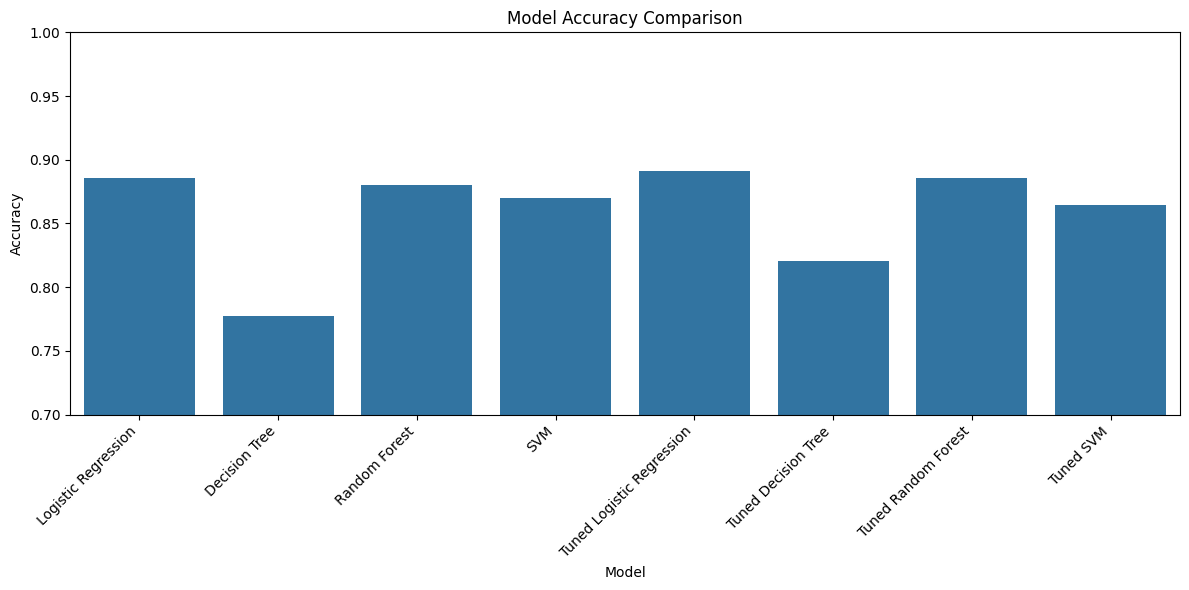

In [120]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=45, ha="right")
plt.ylim(0.70, 1.0)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

Recall

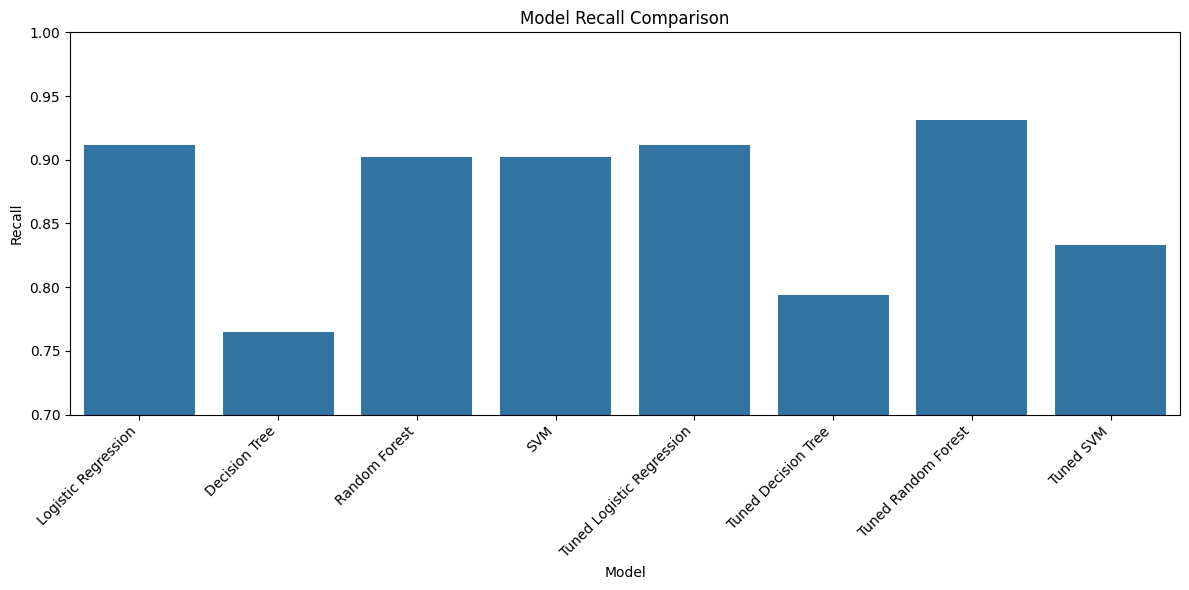

In [121]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results,
    x="Model",
    y="Recall"
)

plt.xticks(rotation=45, ha="right")
plt.ylim(0.70, 1.0)
plt.title("Model Recall Comparison")
plt.ylabel("Recall")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

ROC-AUC

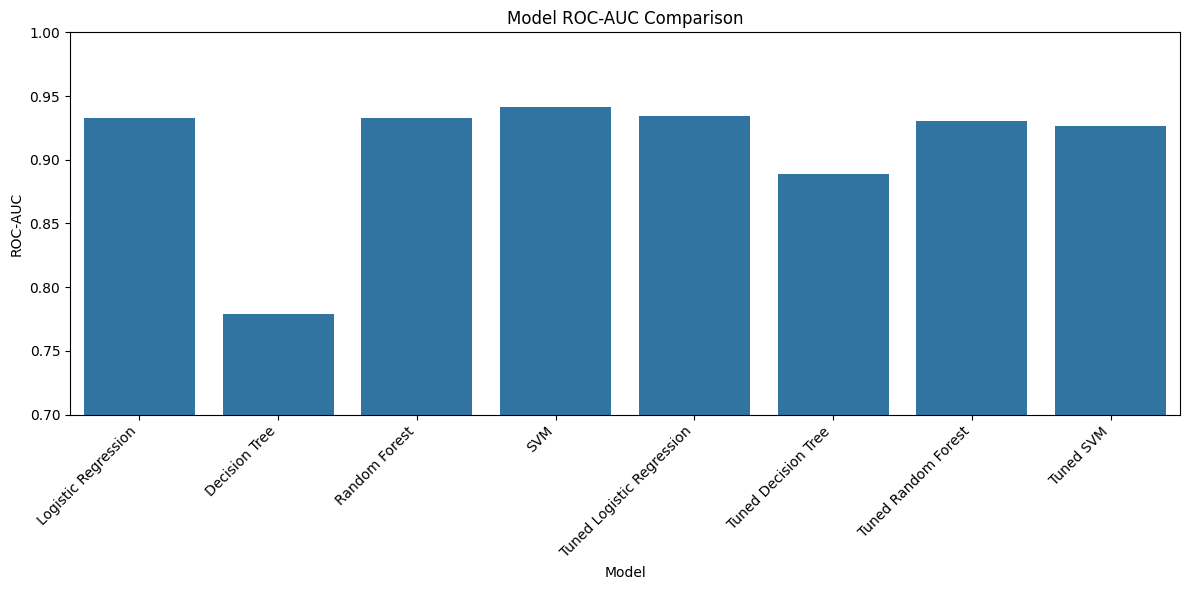

In [122]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results,
    x="Model",
    y="ROC-AUC"
)

plt.xticks(rotation=45, ha="right")
plt.ylim(0.70, 1.0)
plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

ROC Curve + Threshold Analysis

Plot ROC curves for all models

In [123]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

fpr_lr_tuned, tpr_lr_tuned, _ = roc_curve(
    y_test, y_prob_lr_tuned
)

fpr_dt_tuned, tpr_dt_tuned, _ = roc_curve(
    y_test, y_prob_dt_tuned
)

fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(
    y_test, y_prob_rf_tuned
)

fpr_svm_tuned, tpr_svm_tuned, _ = roc_curve(
    y_test, y_prob_svm_tuned
)

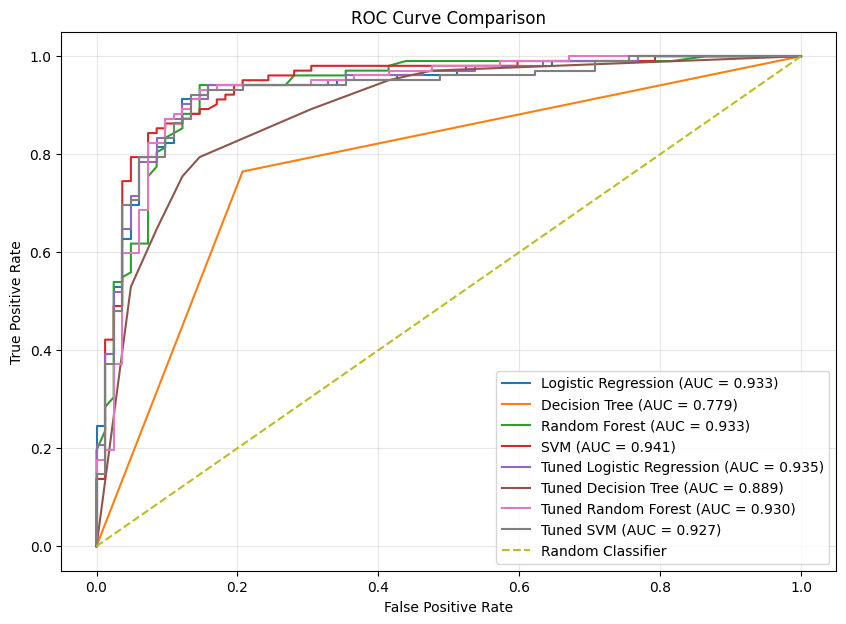

In [124]:
plt.figure(figsize=(10, 7))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_dt:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {roc_auc_svm:.3f})"
)

plt.plot(
    fpr_lr_tuned,
    tpr_lr_tuned,
    label=f"Tuned Logistic Regression (AUC = {roc_auc_lr_tuned:.3f})"
)

plt.plot(
    fpr_dt_tuned,
    tpr_dt_tuned,
    label=f"Tuned Decision Tree (AUC = {roc_auc_dt_tuned:.3f})"
)

plt.plot(
    fpr_rf_tuned,
    tpr_rf_tuned,
    label=f"Tuned Random Forest (AUC = {roc_auc_rf_tuned:.3f})"
)

plt.plot(
    fpr_svm_tuned,
    tpr_svm_tuned,
    label=f"Tuned SVM (AUC = {roc_auc_svm_tuned:.3f})"
)

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Generate cross-validation probabilities

In [125]:
from sklearn.model_selection import cross_val_predict

rf_cv_prob = cross_val_predict(
    best_rf,
    X_train,
    y_train,
    cv=5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

Find the ROC-based optimal threshold

In [126]:
fpr_rf_cv, tpr_rf_cv, thresholds_rf_cv = roc_curve(
    y_train,
    rf_cv_prob
)

In [127]:
youden_j = tpr_rf_cv - fpr_rf_cv

best_index = np.argmax(youden_j)

optimal_threshold = thresholds_rf_cv[best_index]

print("Optimal threshold:", round(optimal_threshold, 4))
print("Sensitivity/Recall:", round(tpr_rf_cv[best_index], 4))
print("Specificity:", round(1 - fpr_rf_cv[best_index], 4))

Optimal threshold: 0.5184
Sensitivity/Recall: 0.9015
Specificity: 0.8171


Apply that threshold to the untouched test set

In [128]:
y_prob_final_rf = best_rf.predict_proba(X_test)[:, 1]

y_pred_rf_threshold = (
    y_prob_final_rf >= optimal_threshold
).astype(int)

In [129]:
accuracy_rf_threshold = accuracy_score(
    y_test,
    y_pred_rf_threshold
)

precision_rf_threshold = precision_score(
    y_test,
    y_pred_rf_threshold
)

recall_rf_threshold = recall_score(
    y_test,
    y_pred_rf_threshold
)

f1_rf_threshold = f1_score(
    y_test,
    y_pred_rf_threshold
)

cm_rf_threshold = confusion_matrix(
    y_test,
    y_pred_rf_threshold
)

tn, fp, fn, tp = cm_rf_threshold.ravel()

specificity_rf_threshold = tn / (tn + fp)

In [130]:
roc_auc_rf_threshold = roc_auc_score(
    y_test,
    y_prob_final_rf
)

Display the threshold result

In [131]:
print("Tuned Random Forest - Threshold Optimized")
print("-------------------------------------------")
print("Threshold  :", round(optimal_threshold, 4))
print("Accuracy   :", round(accuracy_rf_threshold, 4))
print("Precision  :", round(precision_rf_threshold, 4))
print("Recall     :", round(recall_rf_threshold, 4))
print("F1 Score   :", round(f1_rf_threshold, 4))
print("ROC-AUC    :", round(roc_auc_rf_threshold, 4))
print("Specificity:", round(specificity_rf_threshold, 4))

Tuned Random Forest - Threshold Optimized
-------------------------------------------
Threshold  : 0.5184
Accuracy   : 0.8913
Precision  : 0.8796
Recall     : 0.9314
F1 Score   : 0.9048
ROC-AUC    : 0.9301
Specificity: 0.8415


Compare 0.50 vs optimized threshold

In [132]:
threshold_comparison = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Specificity"
    ],

    "Default 0.50": [
        0.50,
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf,
        specificity_rf
    ],

    "Tuned RF 0.50": [
        0.50,
        accuracy_rf_tuned,
        precision_rf_tuned,
        recall_rf_tuned,
        f1_rf_tuned,
        roc_auc_rf_tuned,
        specificity_rf_tuned
    ],

    "Optimized Threshold": [
        optimal_threshold,
        accuracy_rf_threshold,
        precision_rf_threshold,
        recall_rf_threshold,
        f1_rf_threshold,
        roc_auc_rf_threshold,
        specificity_rf_threshold
    ]
})

threshold_comparison.round(4)

,Metric,Default 0.50,Tuned RF 0.50,Optimized Threshold
0,Threshold,0.5000,0.5000,0.5184
1,Accuracy,0.8804,0.8859,0.8913
2,Precision,0.8846,0.8716,0.8796
3,Recall,0.9020,0.9314,0.9314
4,F1 Score,0.8932,0.9005,0.9048
5,ROC-AUC,0.9328,0.9301,0.9301
6,Specificity,0.8537,0.8293,0.8415


Final Model Selection
Tuned Random Forest + optimized threshold 0.5184

Why?
It gives us:

Accuracy     = 89.13%
Precision    = 87.96%
Recall       = 93.14%
F1 Score     = 90.48%
ROC-AUC      = 93.01%
Specificity  = 84.15%

Most importantly:
False Negatives = 7

Save the Final Model

In [133]:
import pickle

In [134]:
final_model_package = {
    "model": best_rf,
    "threshold": optimal_threshold
}

In [135]:
with open("heart_disease_final_model.pkl", "wb") as file:
    pickle.dump(final_model_package, file)

In [136]:
import os

print(
    "File created:",
    os.path.exists("heart_disease_final_model.pkl")
)

print(
    "File size:",
    round(
        os.path.getsize("heart_disease_final_model.pkl") / 1024,
        2
    ),
    "KB"
)

File created: True
File size: 762.51 KB


test the saved model

In [137]:
with open("heart_disease_final_model.pkl", "rb") as file:
    loaded_package = pickle.load(file)

In [138]:
loaded_model = loaded_package["model"]
loaded_threshold = loaded_package["threshold"]

In [139]:
print("Threshold:", loaded_threshold)
print("Model:", loaded_model)

Threshold: 0.5183500182756474
Model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'MaxHR',
                                                   'Oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot

Test prediction from the saved model

In [140]:
loaded_probabilities = loaded_model.predict_proba(X_test)[:, 1]

loaded_predictions = (
    loaded_probabilities >= loaded_threshold
).astype(int)

In [141]:
loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

loaded_recall = recall_score(
    y_test,
    loaded_predictions
)

loaded_f1 = f1_score(
    y_test,
    loaded_predictions
)

In [142]:
print("Loaded Model Test")
print("----------------------------")
print("Accuracy :", round(loaded_accuracy, 4))
print("Recall   :", round(loaded_recall, 4))
print("F1 Score :", round(loaded_f1, 4))

Loaded Model Test
----------------------------
Accuracy : 0.8913
Recall   : 0.9314
F1 Score : 0.9048


In [143]:
new_patient = pd.DataFrame({
    "Age": [55],
    "Sex": ["M"],
    "ChestPainType": ["ATA"],
    "RestingBP": [140],
    "Cholesterol": [250],
    "FastingBS": [0],
    "RestingECG": ["Normal"],
    "MaxHR": [150],
    "ExerciseAngina": ["N"],
    "Oldpeak": [1.0],
    "ST_Slope": ["Up"]
})

new_patient

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,55,M,ATA,140,250,0,Normal,150,N,1.0,Up


In [144]:
with open("heart_disease_final_model.pkl", "rb") as file:
    final_package = pickle.load(file)

final_model = final_package["model"]
final_threshold = final_package["threshold"]

In [145]:
print("Threshold:", final_threshold)

Threshold: 0.5183500182756474


In [146]:
probability = final_model.predict_proba(new_patient)[0, 1]

print("Model score:", round(probability, 4))

Model score: 0.1155


Apply our optimized threshold

In [147]:
prediction = int(probability >= final_threshold)

print("Prediction:", prediction)

Prediction: 0


In [148]:
if prediction == 1:
    result = "Heart Disease Detected"
else:
    result = "No Heart Disease Detected"

print("Result:", result)

Result: No Heart Disease Detected


In [149]:
print("======================================")
print("     HEART DISEASE PREDICTION")
print("======================================")

print("Model Score :", round(probability * 100, 2), "%")
print("Threshold   :", round(final_threshold * 100, 2), "%")
print("Prediction  :", result)

print("======================================")

     HEART DISEASE PREDICTION
Model Score : 11.55 %
Threshold   : 51.84 %
Prediction  : No Heart Disease Detected


In [150]:
def predict_heart_disease(patient_data):

    probability = final_model.predict_proba(patient_data)[0, 1]

    prediction = int(probability >= final_threshold)

    if prediction == 1:
        result = "Heart Disease Detected"
    else:
        result = "No Heart Disease Detected"

    return {
        "prediction": prediction,
        "result": result,
        "model_score": round(probability, 4),
        "threshold": round(final_threshold, 4)
    }

In [151]:
result = predict_heart_disease(new_patient)

print(result)

{'prediction': 0, 'result': 'No Heart Disease Detected', 'model_score': np.float64(0.1155), 'threshold': np.float64(0.5184)}
